# Loading Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
import time

import matplotlib.pyplot as plt
# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Data Augmentation

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
data_generator = ImageDataGenerator(rescale=1./255.,validation_split=0.2,
                                   featurewise_center=True,
        samplewise_center=True,
        featurewise_std_normalization=True,
        samplewise_std_normalization=True,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        zoom_range=0.15,
        fill_mode="nearest",
        horizontal_flip=True,
        vertical_flip=True
                        )
train_generator = data_generator.flow_from_directory(directory= '../input/cough-detection/melspectrograms/training',             
                                                     target_size=(224, 224),
                                                     class_mode='binary',
                                                     subset='training',
                                                     shuffle=True,
                                                     seed=2,
                                                     batch_size=32,
                                                     color_mode='rgb'
                                                     )

valid_generator = data_generator.flow_from_directory(directory= '../input/cough-detection/melspectrograms/testing',
                                                     target_size=(224, 224),
                                                     class_mode='binary',
                                                     subset='validation',
                                                     shuffle=True,
                                                     batch_size=32,
                                                     color_mode='rgb'
                                                    )

classes = ['cough', 'no_cough']

Found 1281 images belonging to 2 classes.
Found 79 images belonging to 2 classes.


# Data Visualization

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: MatplotlibDeprecationWarning: Using a string of single character colors as a color sequence is deprecated. Use an explicit list instead.
  


Text(0.5, 1.0, 'On validation set')

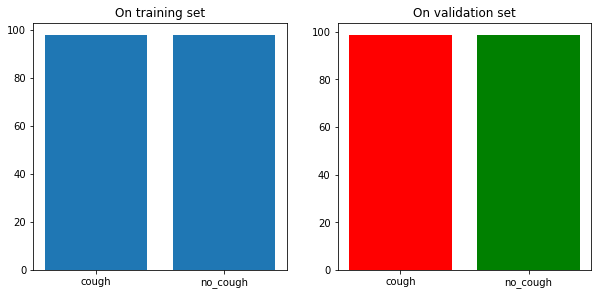

In [3]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.bar(classes, train_generator.labels.sum(axis = 0)/train_generator.n * 100)
plt.title('On training set')
plt.subplot(2,2,2)
plt.bar(classes, valid_generator.labels.sum(axis = 0)/valid_generator.n * 100, color='rgb')
plt.title('On validation set')

In [4]:
sample_training_images, _ = next(train_generator)

/opt/conda/lib/python3.7/site-packages/keras_preprocessing/image/image_data_generator.py:720: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '
/opt/conda/lib/python3.7/site-packages/keras_preprocessing/image/image_data_generator.py:728: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn('This ImageDataGenerator specifies '


In [5]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20,20))
    labels = sample_training_images
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

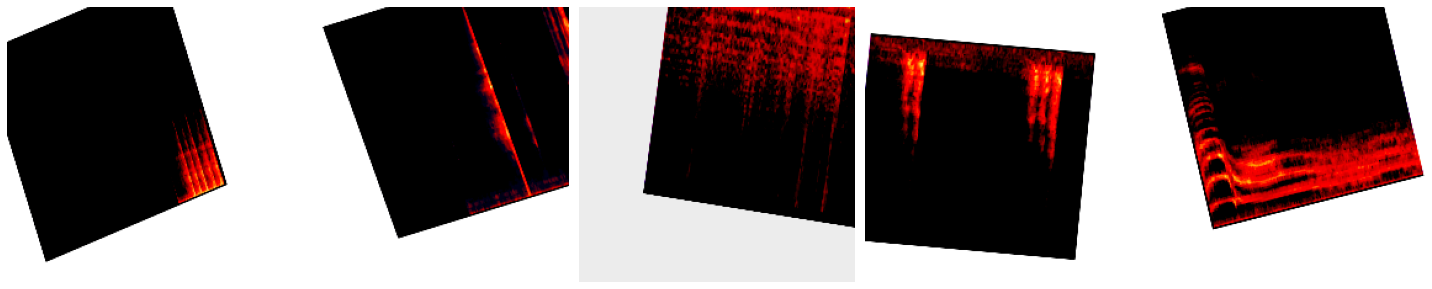

In [6]:
plotImages(sample_training_images[:5])

In [7]:
model = tf.keras.models.Sequential()
model.add(MobileNetV2(include_top=False, pooling='avg', weights='imagenet', input_shape=(224, 224, 3), classes=2))
model.add(Dense(2, activation='softmax'))
model.layers[0].trainable = False
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

9412608/9406464 [==============================] - 0s 0us/step


In [8]:
callbacks = tf.keras.callbacks.EarlyStopping(monitor = 'val_accuracy', patience = 2)
history = model.fit_generator(train_generator,
                              steps_per_epoch = len(train_generator),
                              epochs=15,
                              validation_steps = len(valid_generator),
                              validation_data=valid_generator,
                              callbacks = [callbacks]
                              )

Epoch 1/15
41/41 [==============================] - 27s 658ms/step - loss: 0.1653 - accuracy: 0.9532 - val_loss: 0.0593 - val_accuracy: 0.9873
Epoch 2/15
41/41 [==============================] - 23s 564ms/step - loss: 0.0875 - accuracy: 0.9797 - val_loss: 0.0614 - val_accuracy: 0.9873
Epoch 3/15
41/41 [==============================] - 23s 573ms/step - loss: 0.0753 - accuracy: 0.9789 - val_loss: 0.0496 - val_accuracy: 0.9873


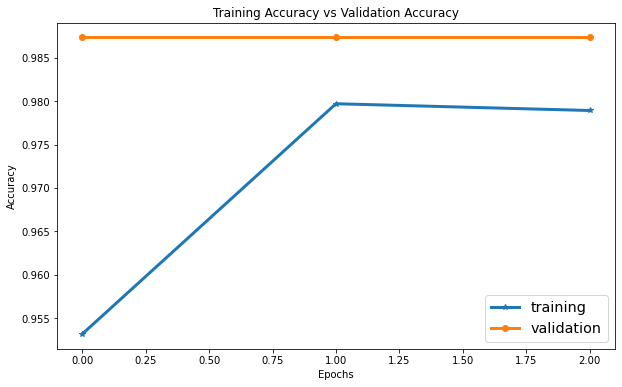

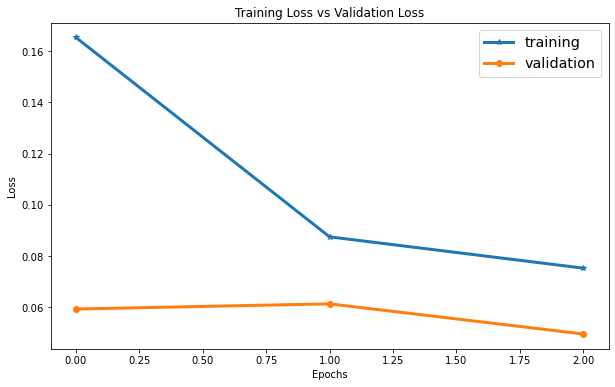

In [9]:
def visualize_training(history, lw = 3):
    plt.figure(figsize=(10,6))
    plt.plot(history.history['accuracy'], label = 'training', marker = '*', linewidth = lw)
    plt.plot(history.history['val_accuracy'], label = 'validation', marker = 'o', linewidth = lw)
    plt.title('Training Accuracy vs Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(fontsize = 'x-large')
    plt.show()

    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label = 'training', marker = '*', linewidth = lw)
    plt.plot(history.history['val_loss'], label = 'validation', marker = 'o', linewidth = lw)
    plt.title('Training Loss vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(fontsize = 'x-large')
    plt.show()
visualize_training(history)

# Predictions

In [10]:
preds = model.predict_generator(valid_generator,steps=15)

In [11]:
label = valid_generator.classes

In [12]:
pred= model.predict(valid_generator)
predicted_class_indices=np.argmax(pred,axis=1)
labels = (valid_generator.class_indices)
labels2 = dict((v,k) for k,v in labels.items())
predictions = [labels2[k] for k in predicted_class_indices]
print(predicted_class_indices)
print (labels)
print (predictions)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1]
{'cough': 0, 'no_cough': 1}
['no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_cough', 'no_c

In [13]:
image_path = '../input/cough-detection/melspectrograms/testing/cough/1-63679-A-24.png'
image = tf.keras.preprocessing.image.load_img(image_path)
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = model.predict(input_arr)

In [14]:
predictions

array([[0.11510015, 0.88489985]], dtype=float32)

In [15]:
image_path = '../input/cough-detection/melspectrograms/testing/no_cough/1-100032-A-0.png'
image = tf.keras.preprocessing.image.load_img(image_path)
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions1 = model.predict(input_arr)

In [16]:
predictions1

array([[0.07951538, 0.9204846 ]], dtype=float32)

# Predicting Non Cough samples

In [17]:
image_path = '../input/cough-detection/melspectrograms/training/no_cough/1-100038-A-14.png'
image = tf.keras.preprocessing.image.load_img(image_path)
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions_nocough = model.predict(input_arr)

In [18]:
predictions_nocough

array([[0.04363999, 0.95636004]], dtype=float32)

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

rc = roc_curve(predicted_class_indices,label)
cf_matrix = confusion_matrix(predicted_class_indices,label)
cf_report = classification_report(predicted_class_indices,label)
print('Confusion matrix report of the model : \n{}'.format(cf_matrix))

Confusion matrix report of the model : 
[[ 0  0]
 [ 1 78]]


/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_ranking.py:805: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  UndefinedMetricWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [20]:
exp_series = pd.Series(label)
pred_series = pd.Series(predicted_class_indices)
pd.crosstab(exp_series, pred_series, rownames=['Actual'], colnames=['Predicted'],margins=True)

Predicted,1,All
Actual,,
0,1,1
1,78,78
All,79,79


In [21]:
print('Classification report of the model : \n{}'.format(cf_report))

Classification report of the model : 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      0.99        79

    accuracy                           0.99        79
   macro avg       0.50      0.49      0.50        79
weighted avg       1.00      0.99      0.99        79



# Saving Model

In [22]:
t = time.time()
save_path = '.'
model_json = model.to_json()
with open(os.path.join(save_path,"network.json"), "w") as json_file:
    json_file.write(model_json)

# save neural network structure to YAML (no weights)
model_yaml = model.to_yaml()
with open(os.path.join(save_path,"network.yaml"), "w") as yaml_file:
    yaml_file.write(model_yaml)

# save entire network to HDF5 (save everything, suggested)
model.save(os.path.join(save_path,"network.h5"))

In [23]:
!ls

__notebook__.ipynb  network.h5	network.json  network.yaml


# Loading the Saved Model and Predictions

In [24]:
from tensorflow.keras.models import load_model
model2 = load_model(os.path.join(save_path,"network.h5"))
pred = model2.predict(input_arr)
pred

array([[0.04363999, 0.95636004]], dtype=float32)